Device : cuda
Seeds  : [42, 123, 256, 789, 999]
Output : D:\22\AA\evaluation\MultiScale_Artifact_Context_Transformer
Experiment: MultiScale CNN + Artifact-Aware (no Focal Loss)
Split loaded -> Train:76  Test:20
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Building datasets...
  Samples  : 71,347
  RAM      : 2.57 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  59,303 (83.1%)
    w=0.4 :     930 (1.3%)
    w=0.2 :   7,686 (10.8%)
    w=0.1 :   3,385 (4.7%)
    w=0.0 :      43 (0.1%)

  Samples  : 19,763
  RAM      : 0.71 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  15,258 (77.2%)
    w=0.4 :     428 (2.2%)
    w=0.2 :   3,306 (16.7%)
    w=0.1 :     771 (3.9%)
Datasets ready.

Class weights:
  Wake: 1.844
  N1: 3.142
  N2: 0.442
  N3: 1.016
  REM: 1.117

SEED 42  (1/5)


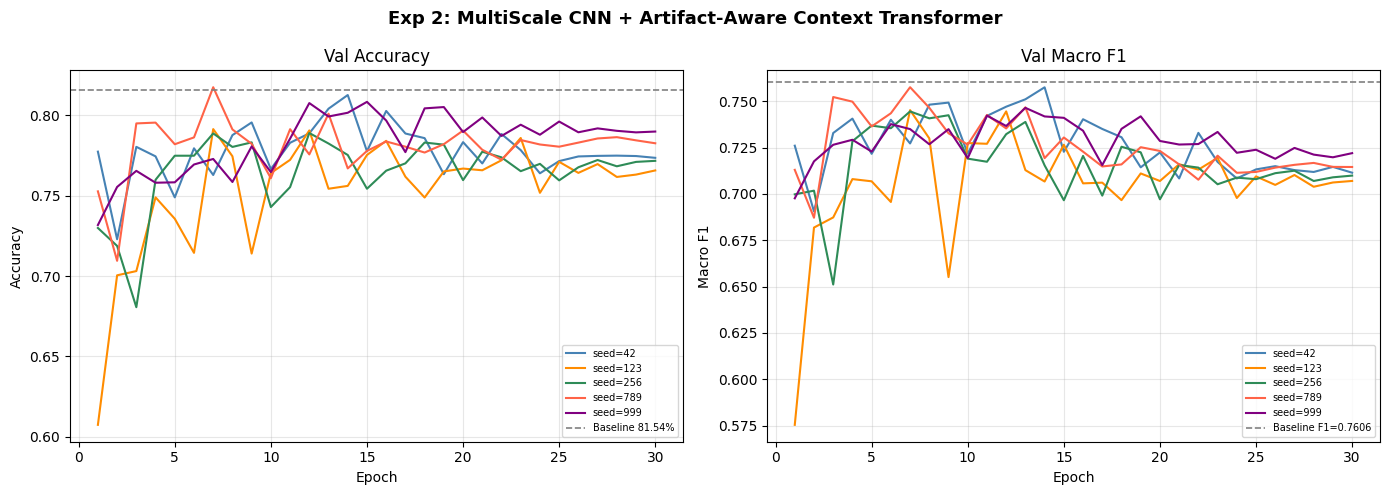

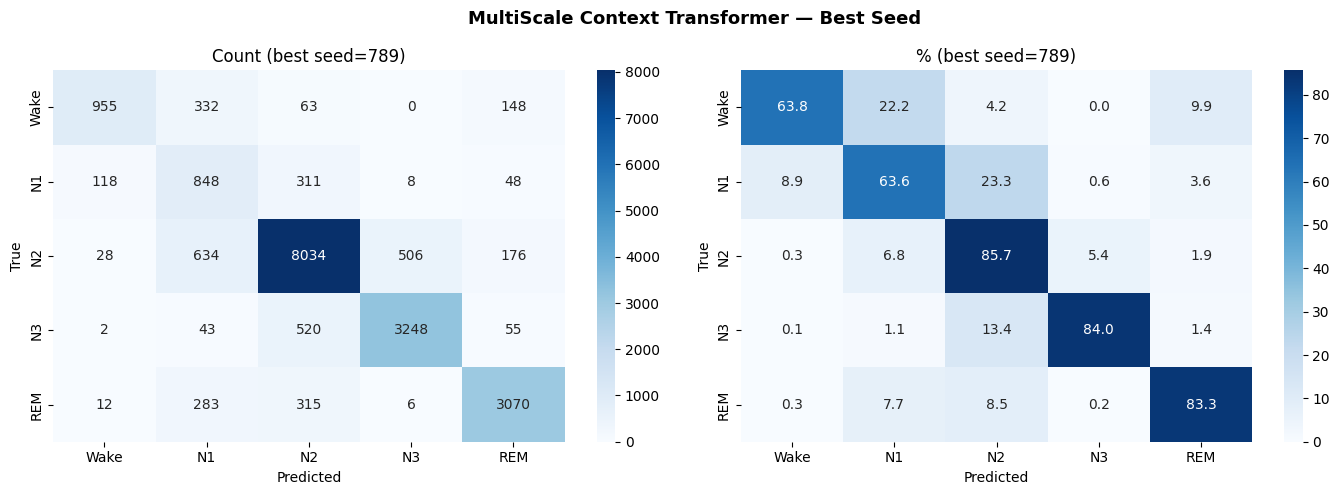

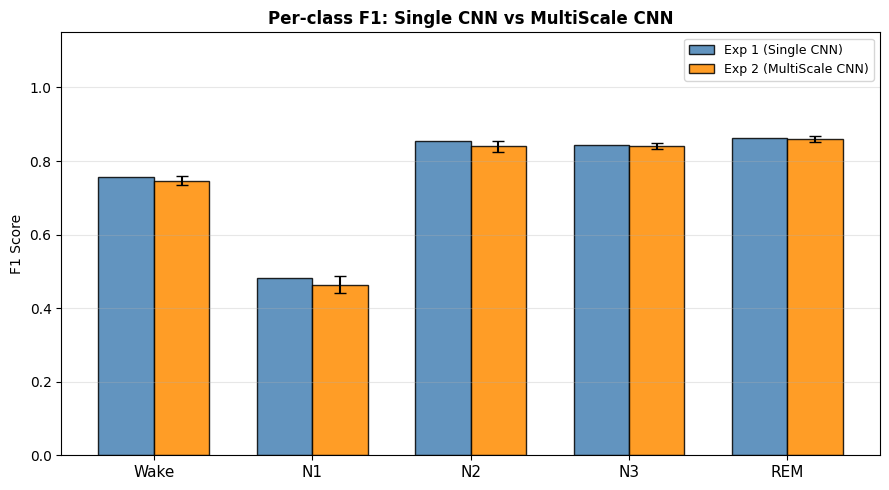


Saved: D:\22\AA\evaluation\MultiScale_Artifact_Context_Transformer
Done!


In [2]:
# ============================================================
# Multi-Scale Artifact-Aware Context CNN + Transformer
# Experiment 2: শুধু CNN block upgrade, Focal Loss নেই
#
# Baseline (Exp 1): Single CNN + Artifact = 81.54%
# This    (Exp 2): MultiScale CNN + Artifact = ???
#
# এতে clearly বোঝা যাবে Multi-Scale CNN কতটা contribute করে
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS & CONFIG
# ============================================================
SAVE_PATH     = r"D:\22\AA\preprocess\preprocessed_FFinal"
ARTIFACT_PATH = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"
EVAL_PATH     = r"D:\22\AA\evaluation\MultiScale_Artifact_Context_Transformer"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 3
WINDOW      = 2 * CONTEXT + 1
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Seeds  : {SEEDS}")
print(f"Output : {EVAL_PATH}")
print(f"Experiment: MultiScale CNN + Artifact-Aware (no Focal Loss)")

# ============================================================
# ARTIFACT CONFIG — same as baseline
# ============================================================
ARTIFACT_WEIGHT_MAP = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_CHANNELS     = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_CHANNELS   = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]


def load_artifact_weights(subject_id, artifact_path, epoch_duration=30):
    tsv_path = os.path.join(
        artifact_path, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return None
    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return None

    available = [ch for ch in TARGET_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_CHANNELS if ch in df.columns]
    if not available:
        return None

    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // epoch_duration).astype(int)
    epoch_scores      = df.groupby('sleep_epoch')['worst_score'].max()

    n_epochs = int(epoch_scores.index.max()) + 1
    weights  = np.ones(n_epochs, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        weights[int(ep_idx)] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)
    return weights


# ============================================================
# FIXED SPLIT — same seed=42 as baseline
# ============================================================
all_subjects = sorted([
    f.replace(".npz", "")
    for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])

_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

if os.path.exists(_train_path) and os.path.exists(_test_path):
    TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
    TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
    print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")
else:
    _subs = all_subjects.copy()
    random.seed(42)
    random.shuffle(_subs)
    n          = int(0.8 * len(_subs))
    TRAIN_SUBS = _subs[:n]
    TEST_SUBS  = _subs[n:]
    np.save(_train_path, np.array(TRAIN_SUBS))
    np.save(_test_path,  np.array(TEST_SUBS))
    print(f"Split created -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print(f"TEST_SUBS: {TEST_SUBS}")


# ============================================================
# DATASET — same as baseline
# ============================================================
class ArtifactAwareDataset(Dataset):
    def __init__(self, subject_list, data_path,
                 artifact_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []

        label_counter  = Counter()
        weight_counter = Counter()
        no_tsv_count   = 0

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue

            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],    :]
                signal = np.concatenate(
                    [eeg, eog], axis=1
                ).astype(np.float32)
                labels = d['labels'].copy()

            n     = len(labels)
            art_w = load_artifact_weights(sub, artifact_path)

            if art_w is None:
                art_w        = np.ones(n, dtype=np.float32)
                no_tsv_count += 1
            else:
                if len(art_w) >= n:
                    art_w = art_w[:n]
                else:
                    art_w = np.concatenate(
                        [art_w, np.ones(n - len(art_w), dtype=np.float32)]
                    )

            sub_idx = len(self.data)
            self.data.append((signal, labels))

            for i in range(n):
                w = float(art_w[i])
                self.index.append((sub_idx, i, n, w))
                label_counter[int(labels[i])] += 1
                weight_counter[round(w, 1)]   += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(5)], dtype=np.float32
        )

        total = len(self.index)
        ram   = sum(s.nbytes for s, _ in self.data) / 1e9
        print(f"  Samples  : {total:,}")
        print(f"  RAM      : {ram:.2f} GB")
        print(f"  No TSV   : {no_tsv_count} subjects")
        print(f"  Weight distribution:")
        for w in sorted(weight_counter.keys(), reverse=True):
            pct = weight_counter[w] / total * 100
            print(f"    w={w:.1f} : {weight_counter[w]:>7,} ({pct:.1f}%)")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])

        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])

        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32)
        )


print("\nBuilding datasets...")
train_ds = ArtifactAwareDataset(TRAIN_SUBS, SAVE_PATH, ARTIFACT_PATH)
print()
test_ds  = ArtifactAwareDataset(TEST_SUBS,  SAVE_PATH, ARTIFACT_PATH)
print("Datasets ready.")


# ============================================================
# POSITIONAL ENCODING
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


# ============================================================
# MULTI-SCALE CNN
# k=25  → spindles / fast components
# k=50  → theta waves (N1/REM)
# k=100 → delta waves (N3)
# k=200 → slow oscillations / K-complex
# ============================================================
class MultiScaleCNN(nn.Module):
    def __init__(self, in_ch, d_model, dropout=0.4):
        super().__init__()
        branch_dim = d_model // 4   # 32 each if d_model=128

        self.branch1 = nn.Sequential(
            nn.Conv1d(in_ch, branch_dim, kernel_size=25,  stride=4, padding=12),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(branch_dim, branch_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
            nn.MaxPool1d(2, 2),
        )
        self.branch2 = nn.Sequential(
            nn.Conv1d(in_ch, branch_dim, kernel_size=50,  stride=4, padding=25),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(branch_dim, branch_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
            nn.MaxPool1d(2, 2),
        )
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_ch, branch_dim, kernel_size=100, stride=4, padding=50),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(branch_dim, branch_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
            nn.MaxPool1d(2, 2),
        )
        self.branch4 = nn.Sequential(
            nn.Conv1d(in_ch, branch_dim, kernel_size=200, stride=4, padding=100),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(branch_dim, branch_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(branch_dim), nn.GELU(),
            nn.MaxPool1d(2, 2),
        )

        self.proj    = nn.Conv1d(4 * branch_dim, d_model, kernel_size=1)
        self.proj_bn = nn.BatchNorm1d(d_model)
        self.drop    = nn.Dropout(dropout)

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)

        min_L = min(b1.size(2), b2.size(2), b3.size(2), b4.size(2))
        b1, b2 = b1[:, :, :min_L], b2[:, :, :min_L]
        b3, b4 = b3[:, :, :min_L], b4[:, :, :min_L]

        out = torch.cat([b1, b2, b3, b4], dim=1)
        out = torch.relu(self.proj_bn(self.proj(out)))
        return self.drop(out)


# ============================================================
# MODEL — MultiScale Context CNN + Transformer
# ============================================================
class MultiScaleContextTransformer(nn.Module):
    def __init__(
        self,
        in_ch     = 3,
        d_model   = 128,
        nhead     = 8,
        num_layers= 3,
        dim_ff    = 256,
        dropout   = 0.4,
        n_classes = 5,
        context   = CONTEXT,
    ):
        super().__init__()
        self.context = context
        self.d_model = d_model

        self.epoch_cnn = MultiScaleCNN(in_ch, d_model, dropout)

        with torch.no_grad():
            intra_len = self.epoch_cnn(torch.zeros(1, in_ch, 3000)).shape[2]
        print(f"  MultiScale CNN output length: {intra_len}")

        self.intra_pos = PositionalEncoding(d_model, max_len=intra_len + 10, dropout=dropout)
        self.intra_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=1
        )

        self.inter_pos = PositionalEncoding(d_model, max_len=WINDOW + 2, dropout=dropout)
        self.inter_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=num_layers
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        feat = self.epoch_cnn(x.view(B * W, C, T)).permute(0, 2, 1)
        feat = self.intra_transformer(self.intra_pos(feat)).mean(dim=1)
        feat = feat.view(B, W, self.d_model)
        feat = self.inter_transformer(self.inter_pos(feat))
        return self.classifier(feat[:, self.context, :])


# ============================================================
# ARTIFACT-WEIGHTED LOSS — CrossEntropy (no Focal)
# same as baseline Exp 1
# ============================================================
def artifact_weighted_loss(logits, labels, weights, class_weights):
    ce_loss  = nn.CrossEntropyLoss(
        weight=class_weights, reduction='none'
    )(logits, labels)
    weighted = ce_loss * weights
    valid    = weights > 0
    if valid.sum() == 0:
        return weighted.mean()
    return weighted[valid].mean()


# ============================================================
# CLASS WEIGHTS
# ============================================================
cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)
cw    = torch.FloatTensor(cw_np).to(device)
print(f"\nClass weights:")
for name, w in zip(LABEL_NAMES, cw_np):
    print(f"  {name}: {w:.3f}")


# ============================================================
# HELPERS
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def train_epoch_fn(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    preds, labs = [], []

    for i, (x, y, w) in enumerate(loader):
        x, y, w = x.to(device), y.to(device), w.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = artifact_weighted_loss(out, y, w, cw)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds.extend(out.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
        if (i + 1) % 300 == 0:
            print(f"  batch {i+1}/{len(loader)}", end="\r")

    acc = accuracy_score(labs, preds)
    f1  = f1_score(labs, preds, average='macro', zero_division=0)
    return total_loss / len(loader), acc, f1


def evaluate_fn(model, loader):
    model.eval()
    preds, labs, weights_all = [], [], []

    with torch.no_grad():
        for x, y, w in loader:
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
            weights_all.extend(w.numpy())

    preds       = np.array(preds)
    labs        = np.array(labs)
    weights_all = np.array(weights_all)

    acc     = accuracy_score(labs, preds)
    f1      = f1_score(labs, preds, average='macro',    zero_division=0)
    kappa   = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None,       zero_division=0)

    clean_mask = weights_all == 1.0
    noisy_mask = (weights_all > 0) & (weights_all < 1.0)
    clean_acc  = accuracy_score(labs[clean_mask], preds[clean_mask]) \
                 if clean_mask.sum() > 0 else 0.0
    noisy_acc  = accuracy_score(labs[noisy_mask], preds[noisy_mask]) \
                 if noisy_mask.sum() > 0 else 0.0

    return (acc, f1, kappa, per_cls, preds, labs,
            clean_acc, noisy_acc,
            int(clean_mask.sum()), int(noisy_mask.sum()))


# ============================================================
# CSV SETUP
# ============================================================
csv_epoch_path = os.path.join(EVAL_PATH, "all_seeds_epoch_log.csv")
with open(csv_epoch_path, 'w', newline='') as f:
    csv.writer(f).writerow([
        'seed', 'epoch', 'tr_loss', 'tr_acc', 'tr_f1',
        'vl_acc', 'vl_f1', 'vl_kappa', 'clean_acc', 'noisy_acc'
    ])

csv_summary_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa",
          "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
          "clean_acc", "noisy_acc"]
with open(csv_summary_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()


# ============================================================
# 5-SEED TRAINING LOOP
# ============================================================
all_seed_results = []
all_cms          = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"SEED {seed}  ({seed_idx + 1}/{len(SEEDS)})")
    print(f"{'='*60}")

    set_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0
    )

    model    = MultiScaleContextTransformer().to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")

    optimizer    = optim.AdamW(
        model.parameters(),
        lr=5e-4, weight_decay=3e-4,
        betas=(0.9, 0.98), eps=1e-9
    )
    total_steps  = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)

    best_f1   = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")
    history   = []

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_epoch_fn(
            model, train_loader, optimizer, scheduler
        )
        (vl_acc, vl_f1, vl_kap, vl_per,
         _, _, clean_acc, noisy_acc,
         n_clean, n_noisy) = evaluate_fn(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch': epoch,
            'tr_loss': tr_loss, 'tr_acc': tr_acc, 'tr_f1': tr_f1,
            'vl_acc': vl_acc,   'vl_f1': vl_f1,   'vl_kap': vl_kap,
            'clean_acc': clean_acc, 'noisy_acc': noisy_acc
        })

        print(
            f"  Ep[{epoch:02d}/{N_EPOCHS}] "
            f"Loss:{tr_loss:.3f} TrAcc:{tr_acc:.3f} "
            f"ValAcc:{vl_acc:.3f} F1:{vl_f1:.3f} "
            f"k:{vl_kap:.3f} LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("    Per-class F1: " + " | ".join(
                f"{LABEL_NAMES[i]}={vl_per[i]:.3f}" for i in range(5)
            ))
            print(f"    Clean:{clean_acc:.3f}({n_clean})  "
                  f"Noisy:{noisy_acc:.3f}({n_noisy})")

        with open(csv_epoch_path, 'a', newline='') as f:
            csv.writer(f).writerow([
                seed, epoch,
                f"{tr_loss:.4f}", f"{tr_acc:.4f}", f"{tr_f1:.4f}",
                f"{vl_acc:.4f}", f"{vl_f1:.4f}", f"{vl_kap:.4f}",
                f"{clean_acc:.4f}", f"{noisy_acc:.4f}"
            ])

    # Final eval
    model.load_state_dict(torch.load(best_path, map_location=device))
    (fin_acc, fin_f1, fin_kap, fin_per,
     fin_preds, fin_labels,
     fin_clean_acc, fin_noisy_acc,
     fin_n_clean, fin_n_noisy) = evaluate_fn(model, test_loader)

    fin_cm = confusion_matrix(fin_labels, fin_preds)
    all_cms.append(fin_cm)

    print(f"\n  Seed {seed} FINAL:")
    print(f"  {'='*51}")
    print(f"  Accuracy    : {fin_acc*100:.2f}%")
    print(f"  Macro F1    : {fin_f1:.4f}")
    print(f"  Kappa       : {fin_kap:.4f}")
    print(f"  Clean Acc   : {fin_clean_acc*100:.2f}% ({fin_n_clean})")
    print(f"  Noisy Acc   : {fin_noisy_acc*100:.2f}% ({fin_n_noisy})")
    print(f"  {'-'*51}")
    print("  Per-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        bar = chr(9608) * int(fin_per[i] * 16)
        print(f"    {name:6s}: {fin_per[i]:.4f}  {bar}")
    print(f"  {'='*51}")

    result = {
        'seed': seed, 'acc': fin_acc, 'f1': fin_f1, 'kappa': fin_kap,
        'per_cls': fin_per, 'clean_acc': fin_clean_acc,
        'noisy_acc': fin_noisy_acc, 'n_clean': fin_n_clean,
        'n_noisy': fin_n_noisy, 'preds': fin_preds,
        'labels': fin_labels, 'history': history,
    }
    all_seed_results.append(result)

    with open(csv_summary_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed": seed, "acc": round(fin_acc, 4),
            "f1_macro": round(fin_f1, 4), "kappa": round(fin_kap, 4),
            "f1_Wake": round(fin_per[0], 4), "f1_N1": round(fin_per[1], 4),
            "f1_N2":   round(fin_per[2], 4), "f1_N3": round(fin_per[3], 4),
            "f1_REM":  round(fin_per[4], 4),
            "clean_acc": round(fin_clean_acc, 4),
            "noisy_acc": round(fin_noisy_acc, 4),
        })


# ============================================================
# FINAL REPORT
# ============================================================
print(f"\n{'='*60}")
print("5-SEED FINAL REPORT")
print(f"Exp 1 (baseline): Single CNN + Artifact = 81.54 +- 0.44%")
print(f"Exp 2 (this)    : MultiScale CNN + Artifact = ???")
print(f"{'='*60}")

accs   = np.array([r['acc']        for r in all_seed_results]) * 100
f1s    = np.array([r['f1']         for r in all_seed_results])
kappas = np.array([r['kappa']      for r in all_seed_results])
n1s    = np.array([r['per_cls'][1] for r in all_seed_results])
c_accs = np.array([r['clean_acc']  for r in all_seed_results]) * 100
n_accs = np.array([r['noisy_acc']  for r in all_seed_results]) * 100

print(f"\n{'Seed':<8} {'Acc%':>7} {'F1':>7} {'Kappa':>7} "
      f"{'N1':>7} {'CleanAcc':>10} {'NoisyAcc':>10}")
print("-" * 60)
for r in all_seed_results:
    print(f"{r['seed']:<8} {r['acc']*100:>7.2f} {r['f1']:>7.4f} "
          f"{r['kappa']:>7.4f} {r['per_cls'][1]:>7.4f} "
          f"{r['clean_acc']*100:>10.2f} {r['noisy_acc']*100:>10.2f}")
print("-" * 60)
print(f"{'Mean':<8} {accs.mean():>7.2f} {f1s.mean():>7.4f} "
      f"{kappas.mean():>7.4f} {n1s.mean():>7.4f} "
      f"{c_accs.mean():>10.2f} {n_accs.mean():>10.2f}")
print(f"{'Std':<8} {accs.std():>7.2f} {f1s.std():>7.4f} "
      f"{kappas.std():>7.4f} {n1s.std():>7.4f} "
      f"{c_accs.std():>10.2f} {n_accs.std():>10.2f}")

print(f"\nPaper format:")
print(f"  Accuracy : {accs.mean():.2f} +- {accs.std():.2f}%")
print(f"  Macro F1 : {f1s.mean():.4f} +- {f1s.std():.4f}")
print(f"  Kappa    : {kappas.mean():.4f} +- {kappas.std():.4f}")
print(f"  N1 F1    : {n1s.mean():.4f} +- {n1s.std():.4f}")

print(f"\nPer-class F1 (mean +- std):")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r['per_cls'][i] for r in all_seed_results])
    print(f"  {name:6s}: {vals.mean():.4f} +- {vals.std():.4f}")

print(f"\nComparison:")
print(f"  Exp 1 (Single CNN)    : 81.54 +- 0.44%  F1=0.7606")
print(f"  Exp 2 (MultiScale CNN): {accs.mean():.2f} +- {accs.std():.2f}%  F1={f1s.mean():.4f}")
diff_acc = accs.mean() - 81.54
diff_f1  = f1s.mean() - 0.7606
print(f"  Change: Acc {diff_acc:+.2f}%  F1 {diff_f1:+.4f}")

# Summary CSV
with open(csv_summary_path, 'a', newline='') as f:
    w = csv.DictWriter(f, fields)
    w.writerow({"seed": "mean", "acc": round(accs.mean()/100, 4),
                "f1_macro": round(f1s.mean(), 4), "kappa": round(kappas.mean(), 4),
                "f1_Wake": round(np.mean([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":   round(np.mean([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":   round(np.mean([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":   round(np.mean([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":  round(np.mean([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.mean()/100, 4),
                "noisy_acc": round(n_accs.mean()/100, 4)})
    w.writerow({"seed": "std", "acc": round(accs.std()/100, 4),
                "f1_macro": round(f1s.std(), 4), "kappa": round(kappas.std(), 4),
                "f1_Wake": round(np.std([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":   round(np.std([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":   round(np.std([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":   round(np.std([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":  round(np.std([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.std()/100, 4),
                "noisy_acc": round(n_accs.std()/100, 4)})

print(f"\nSummary saved: {csv_summary_path}")


# ============================================================
# PLOTS
# ============================================================
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for r, c in zip(all_seed_results, colors):
    h   = r['history']
    eps = [x['epoch'] for x in h]
    axes[0].plot(eps, [x['vl_acc'] for x in h], color=c, lw=1.5, label=f"seed={r['seed']}")
    axes[1].plot(eps, [x['vl_f1']  for x in h], color=c, lw=1.5, label=f"seed={r['seed']}")

axes[0].axhline(0.8154, color='gray', ls='--', lw=1.2, label='Baseline 81.54%')
axes[1].axhline(0.7606, color='gray', ls='--', lw=1.2, label='Baseline F1=0.7606')

for ax, title, ylabel in zip(
    axes, ["Val Accuracy", "Val Macro F1"], ["Accuracy", "Macro F1"]
):
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel); ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig.suptitle("Exp 2: MultiScale CNN + Artifact-Aware Context Transformer",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "training_curves_5seeds.png"), dpi=150)
plt.show()

best_r = max(all_seed_results, key=lambda r: r['f1'])
cm     = confusion_matrix(best_r['labels'], best_r['preds'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title(f"Count (best seed={best_r['seed']})")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title(f"% (best seed={best_r['seed']})")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
fig.suptitle("MultiScale Context Transformer — Best Seed", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_seed.png"), dpi=150)
plt.show()

per_means = np.array([[r['per_cls'][i] for r in all_seed_results] for i in range(5)]).mean(axis=1)
per_stds  = np.array([[r['per_cls'][i] for r in all_seed_results] for i in range(5)]).std(axis=1)

# Baseline per-class for comparison
baseline_per = [0.7570, 0.4830, 0.8555, 0.8436, 0.8637]

x     = np.arange(5)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, baseline_per, width, label='Exp 1 (Single CNN)',
       color='steelblue', alpha=0.85, edgecolor='black')
ax.bar(x + width/2, per_means, width, yerr=per_stds, capsize=4,
       label='Exp 2 (MultiScale CNN)', color='darkorange', alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.15)
ax.set_title("Per-class F1: Single CNN vs MultiScale CNN", fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "per_class_comparison.png"), dpi=150)
plt.show()

print(f"\nSaved: {EVAL_PATH}")
print("Done!")